# Klasifikasi Gambar Sampah dengan CNN pada Dataset TrashType Image Dataset

## Dataset Yang Digunakan

Dataset yang digunakan adalah **TrashType Image Dataset**, sebuah dataset berisi gambar-gambar sampah yang dikelompokkan ke dalam 6 kategori. Dataset ini tersedia di Kaggle dan sering dipakai untuk penelitian klasifikasi sampah berbasis kecerdasan buatan, dengan tujuan mendukung sistem pemilahan sampah otomatis.

Dataset terdiri dari **2.527 gambar** yang terbagi ke dalam 6 kelas:
- **cardboard** : 403 gambar
- **glass** : 501 gambar
- **metal** : 410 gambar
- **paper** : 594 gambar
- **plastic** : 482 gambar
- **trash** : 137 gambar

Setiap gambar berukuran asli **512×384 piksel** dalam format RGB, kemudian di-resize menjadi **64×64 piksel** untuk efisiensi komputasi.

## Gambaran Program

Program ini membangun model CNN dari nol untuk mengklasifikasikan gambar sampah ke dalam 6 kategori menggunakan TensorFlow/Keras.

## 1. Import Library

In [3]:
import subprocess, sys, os, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + list(args))

pip("numpy<2", "matplotlib", "pillow", "scikit-learn", "pandas")
pip("tensorflow==2.10.0")
print("Install selesai.")

Install selesai.


In [5]:
from PIL import Image
from io import BytesIO

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, f1_score, classification_report
)

tf.random.set_seed(42)
np.random.seed(42)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

gpus = tf.config.list_physical_devices("GPU")
gpu_info = gpus[0].name if gpus else "Tidak ada, pakai CPU"
print(f"NumPy version      : {np.__version__}")
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU tersedia       : {gpu_info}")

NumPy version      : 1.26.4
TensorFlow version : 2.10.0
Keras version      : 2.10.0
GPU tersedia       : Tidak ada, pakai CPU


## 2. Load Dataset dari ZIP

In [6]:
ZIP_PATH   = "Garbage Image Dataset.zip"
IMG_SIZE   = (64, 64)
CATEGORIES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

X_list = []
y_list = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    all_files = zf.namelist()
    for label_idx, cat in enumerate(CATEGORIES):
        cat_files = [
            f for f in all_files
            if f"/{cat}/" in f.lower()
            and f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        for fname in cat_files:
            try:
                with zf.open(fname) as img_file:
                    img = Image.open(BytesIO(img_file.read())).convert("RGB")
                    img = img.resize(IMG_SIZE)
                    arr = np.array(img, dtype=np.float32) / 255.0
                    X_list.append(arr)
                    y_list.append(label_idx)
            except Exception:
                pass

X = np.array(X_list)
y = np.array(y_list)

print(f"Total gambar dimuat  : {len(X)}")
print(f"Shape X              : {X.shape}")
print(f"Jumlah kelas         : {len(CATEGORIES)}")
print()
for i, cat in enumerate(CATEGORIES):
    print(f"  {cat:12s}: {np.sum(y == i)} gambar")

Total gambar dimuat  : 2527
Shape X              : (2527, 64, 64, 3)
Jumlah kelas         : 6

  cardboard   : 403 gambar
  glass       : 501 gambar
  metal       : 410 gambar
  paper       : 594 gambar
  plastic     : 482 gambar
  trash       : 137 gambar


## 3. Train-Test Split

In [7]:
TEST_SIZE   = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

y_train_cat = to_categorical(y_train, num_classes=len(CATEGORIES))
y_test_cat  = to_categorical(y_test,  num_classes=len(CATEGORIES))

print(f"Data training  : {len(X_train)} gambar ({int((1-TEST_SIZE)*100)}%)")
print(f"Data testing   : {len(X_test)} gambar ({int(TEST_SIZE*100)}%)")
print()
print("Distribusi training:")
for i, cat in enumerate(CATEGORIES):
    print(f"  {cat:12s}: {np.sum(y_train == i)}")
print("Distribusi testing:")
for i, cat in enumerate(CATEGORIES):
    print(f"  {cat:12s}: {np.sum(y_test == i)}")

Data training  : 2021 gambar (80%)
Data testing   : 506 gambar (20%)

Distribusi training:
  cardboard   : 322
  glass       : 401
  metal       : 328
  paper       : 475
  plastic     : 385
  trash       : 110
Distribusi testing:
  cardboard   : 81
  glass       : 100
  metal       : 82
  paper       : 119
  plastic     : 97
  trash       : 27


## 4. Visualisasi Sampel per Kelas

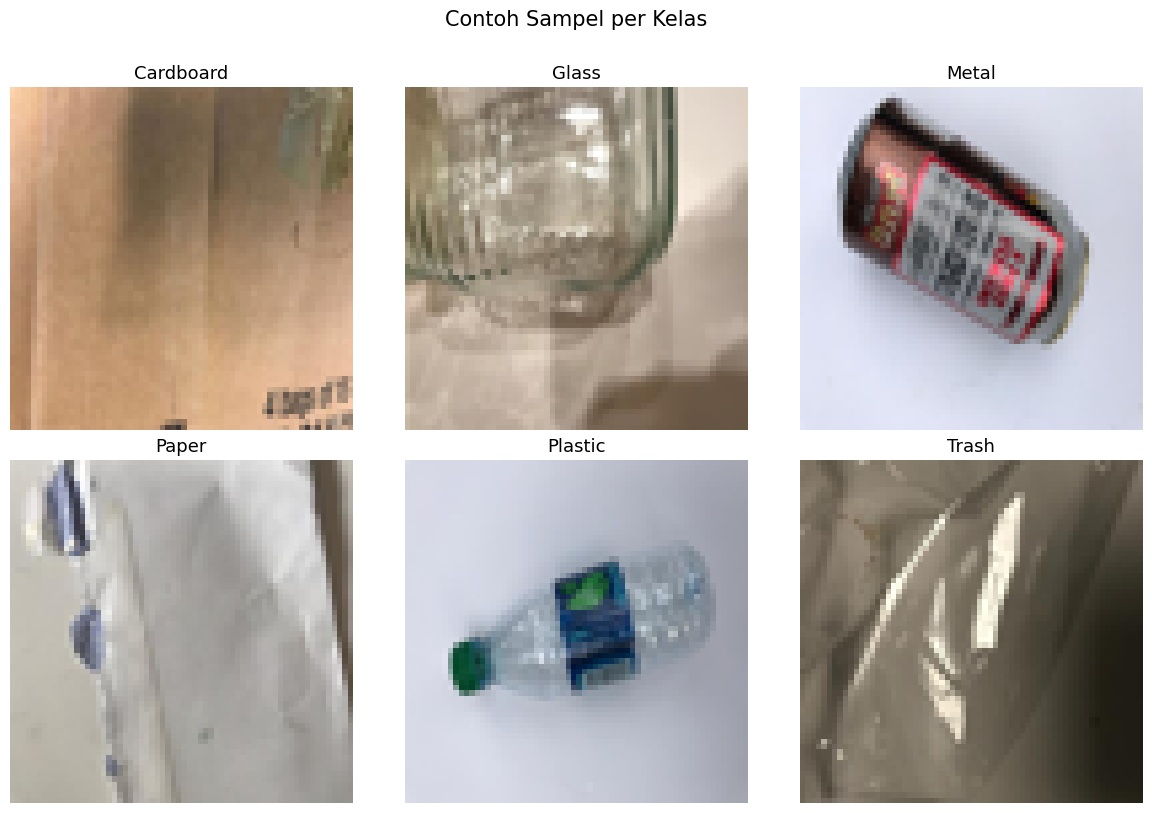

Visualisasi sampel tersimpan.


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, cat in enumerate(CATEGORIES):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx])
    axes[i].set_title(f"{cat.capitalize()}", fontsize=13)
    axes[i].axis("off")

plt.suptitle("Contoh Sampel per Kelas", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualisasi sampel tersimpan.")

## 5. Arsitektur Model CNN

In [9]:
CNN_PARAMS = {
    "input_shape"  : (64, 64, 3),
    "num_classes"  : len(CATEGORIES),
    "filters"      : [32, 64, 128],
    "kernel_size"  : (3, 3),
    "pool_size"    : (2, 2),
    "dense_units"  : 256,
    "dropout_rate" : 0.5,
    "activation"   : "relu",
    "optimizer"    : "adam",
    "loss"         : "categorical_crossentropy",
}

TRAIN_PARAMS = {
    "epochs"           : 20,
    "batch_size"       : 32,
    "validation_split" : 0.1,
}

print("Parameter CNN:")
for k, v in CNN_PARAMS.items():
    print(f"  {k:20s}: {v}")
print()
print("Parameter Training:")
for k, v in TRAIN_PARAMS.items():
    print(f"  {k:20s}: {v}")

Parameter CNN:
  input_shape         : (64, 64, 3)
  num_classes         : 6
  filters             : [32, 64, 128]
  kernel_size         : (3, 3)
  pool_size           : (2, 2)
  dense_units         : 256
  dropout_rate        : 0.5
  activation          : relu
  optimizer           : adam
  loss                : categorical_crossentropy

Parameter Training:
  epochs              : 20
  batch_size          : 32
  validation_split    : 0.1


In [10]:
def build_cnn(params):
    model = models.Sequential([
        layers.Input(shape=params["input_shape"]),

        layers.Conv2D(params["filters"][0], params["kernel_size"], activation=params["activation"], padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(params["pool_size"]),

        layers.Conv2D(params["filters"][1], params["kernel_size"], activation=params["activation"], padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(params["pool_size"]),

        layers.Conv2D(params["filters"][2], params["kernel_size"], activation=params["activation"], padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(params["pool_size"]),

        layers.Flatten(),
        layers.Dense(params["dense_units"], activation=params["activation"]),
        layers.Dropout(params["dropout_rate"]),
        layers.Dense(params["num_classes"], activation="softmax")
    ])
    model.compile(
        optimizer=params["optimizer"],
        loss=params["loss"],
        metrics=["accuracy"]
    )
    return model

model = build_cnn(CNN_PARAMS)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 64)       256       
 hNormalization)                                                 
                                                        

## 6. Training Model

In [11]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print(f"Memulai training selama maksimal {TRAIN_PARAMS['epochs']} epoch ...")
history = model.fit(
    X_train, y_train_cat,
    epochs=TRAIN_PARAMS["epochs"],
    batch_size=TRAIN_PARAMS["batch_size"],
    validation_split=TRAIN_PARAMS["validation_split"],
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Training selesai.")

Memulai training selama maksimal 20 epoch ...
Epoch 1/20
57/57 [==============================] - 10s 164ms/step - loss: 2.2896 - accuracy: 0.4395 - val_loss: 9.2359 - val_accuracy: 0.1921 - lr: 0.0010
Epoch 2/20
57/57 [==============================] - 8s 147ms/step - loss: 1.2463 - accuracy: 0.5407 - val_loss: 13.9174 - val_accuracy: 0.1921 - lr: 0.0010
Epoch 3/20
57/57 [==============================] - 9s 150ms/step - loss: 1.2000 - accuracy: 0.5693 - val_loss: 11.6592 - val_accuracy: 0.1921 - lr: 0.0010
Epoch 4/20
57/57 [==============================] - 8s 148ms/step - loss: 1.1017 - accuracy: 0.6084 - val_loss: 7.8651 - val_accuracy: 0.1921 - lr: 0.0010
Epoch 5/20
57/57 [==============================] - 8s 148ms/step - loss: 1.0247 - accuracy: 0.6254 - val_loss: 3.3908 - val_accuracy: 0.2759 - lr: 0.0010
Epoch 6/20
57/57 [==============================] - 8s 149ms/step - loss: 0.9267 - accuracy: 0.6595 - val_loss: 3.2540 - val_accuracy: 0.2956 - lr: 0.0010
Epoch 7/20
57/57 [===

## 7. Visualisasi Kurva Training

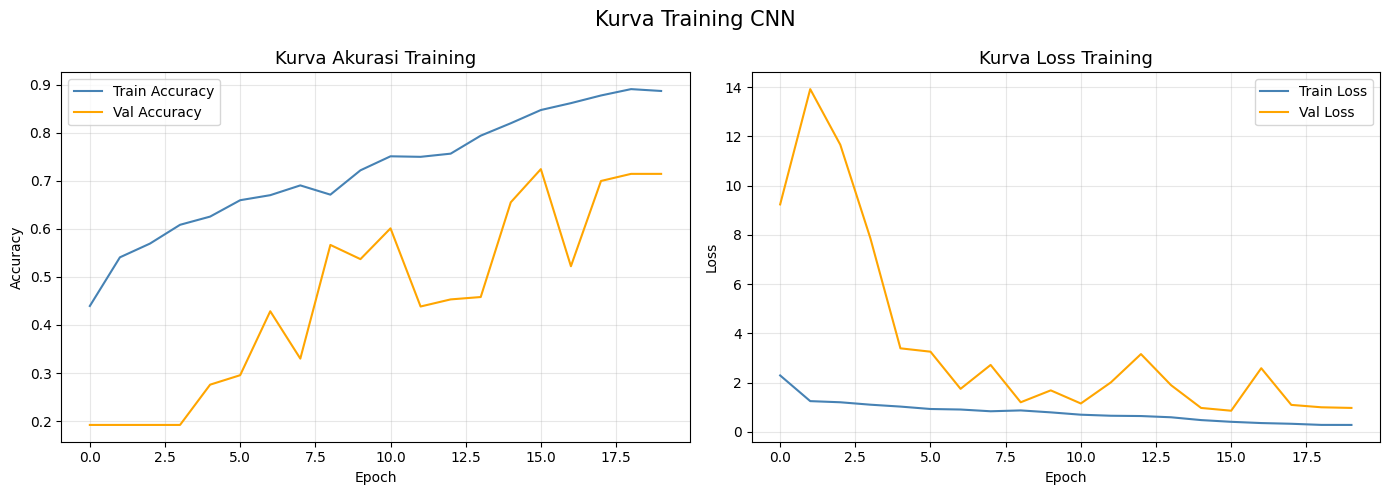

Kurva training tersimpan.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"],     label="Train Accuracy", color="steelblue")
ax1.plot(history.history["val_accuracy"], label="Val Accuracy",   color="orange")
ax1.set_title("Kurva Akurasi Training", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["loss"],     label="Train Loss", color="steelblue")
ax2.plot(history.history["val_loss"], label="Val Loss",   color="orange")
ax2.set_title("Kurva Loss Training", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Kurva Training CNN", fontsize=15)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=100, bbox_inches="tight")
plt.show()
print("Kurva training tersimpan.")

## 8. Prediksi dan Evaluasi dengan Sklearn

In [13]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

print("="*50)
print("         HASIL EVALUASI MODEL CNN")
print("="*50)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CATEGORIES, zero_division=0))

         HASIL EVALUASI MODEL CNN
  Accuracy  : 0.7233  (72.33%)
  Precision : 0.7239
  F1-Score  : 0.7221

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.83      0.77      0.79        81
       glass       0.66      0.62      0.64       100
       metal       0.72      0.66      0.69        82
       paper       0.80      0.87      0.83       119
     plastic       0.64      0.72      0.68        97
       trash       0.65      0.56      0.60        27

    accuracy                           0.72       506
   macro avg       0.72      0.70      0.70       506
weighted avg       0.72      0.72      0.72       506



## 9. Confusion Matrix

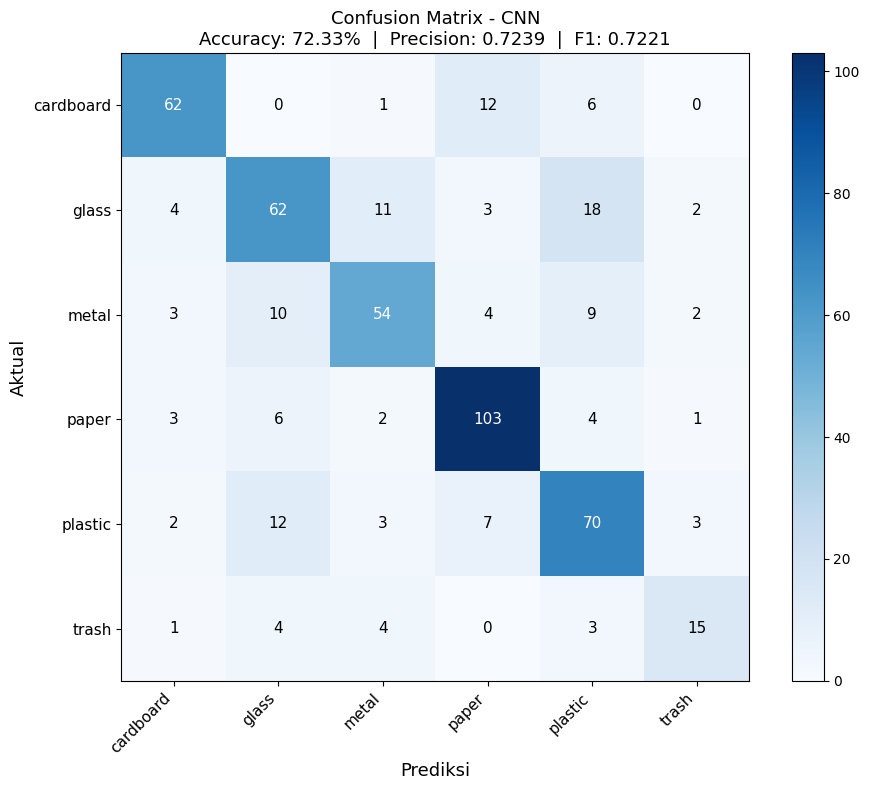

Confusion matrix tersimpan.


In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

tick_marks = np.arange(len(CATEGORIES))
ax.set_xticks(tick_marks)
ax.set_xticklabels(CATEGORIES, rotation=45, ha="right", fontsize=11)
ax.set_yticks(tick_marks)
ax.set_yticklabels(CATEGORIES, fontsize=11)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > thresh else "black")

ax.set_xlabel("Prediksi", fontsize=13)
ax.set_ylabel("Aktual", fontsize=13)
ax.set_title(
    f"Confusion Matrix - CNN\n"
    f"Accuracy: {accuracy*100:.2f}%  |  Precision: {precision:.4f}  |  F1: {f1:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("Confusion matrix tersimpan.")

## 10. Akurasi Per Kelas

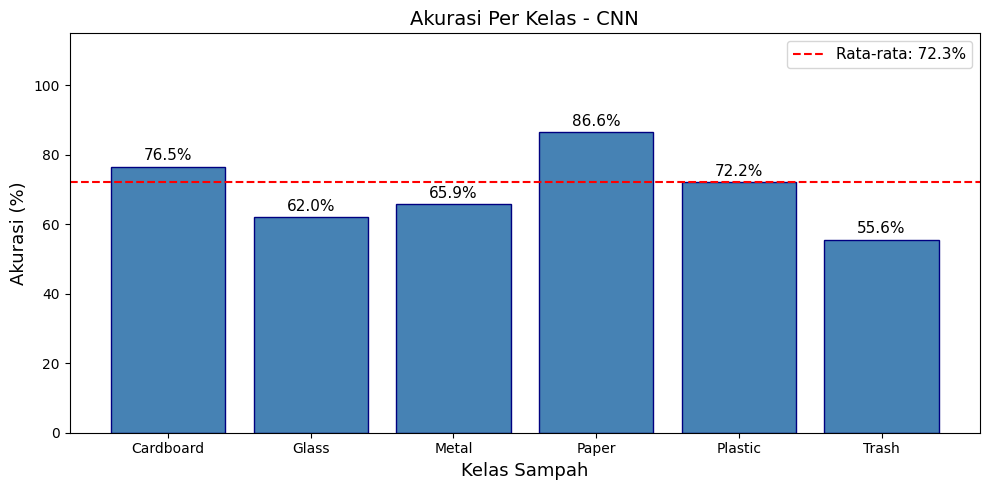

Bar chart akurasi per kelas tersimpan.


In [15]:
per_class_acc = []
for i in range(len(CATEGORIES)):
    mask = y_true == i
    acc_cls = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else 0.0
    per_class_acc.append(acc_cls)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [c.capitalize() for c in CATEGORIES],
    [a * 100 for a in per_class_acc],
    color="steelblue", edgecolor="navy"
)
for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=11
    )

ax.set_xlabel("Kelas Sampah", fontsize=13)
ax.set_ylabel("Akurasi (%)", fontsize=13)
ax.set_title("Akurasi Per Kelas - CNN", fontsize=14)
ax.set_ylim(0, 115)
ax.axhline(y=accuracy * 100, color="red", linestyle="--", label=f"Rata-rata: {accuracy*100:.1f}%")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()
print("Bar chart akurasi per kelas tersimpan.")

## 11. Prediksi Visual pada Data Test

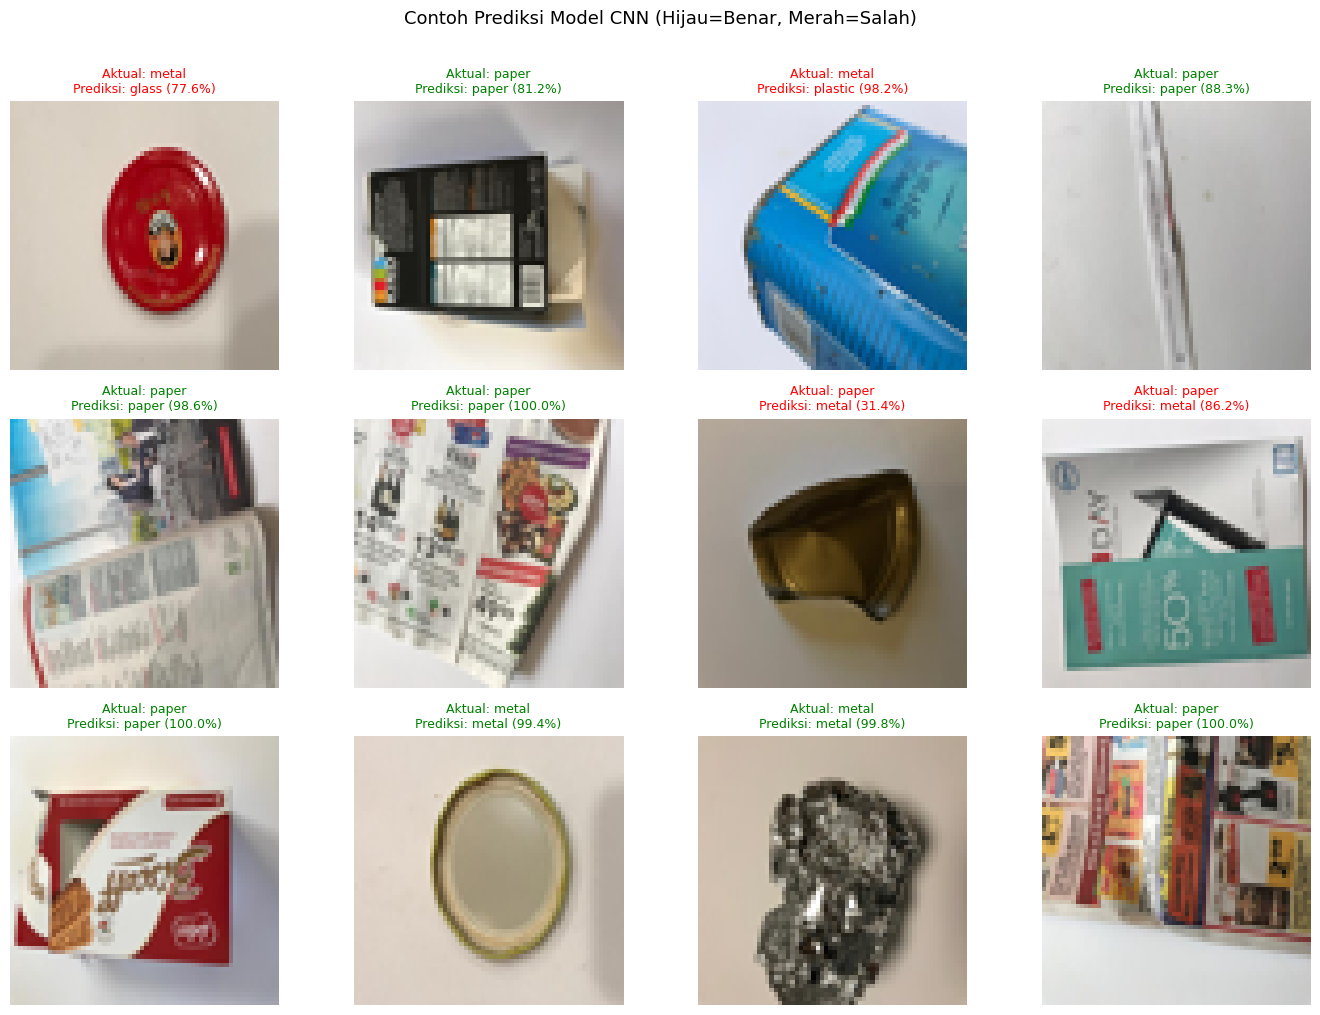

Visualisasi prediksi tersimpan.


In [16]:
np.random.seed(0)
sample_idx = np.random.choice(len(X_test), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()

for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_test[idx])
    true_label = CATEGORIES[y_true[idx]]
    pred_label = CATEGORIES[y_pred[idx]]
    conf       = y_pred_prob[idx][y_pred[idx]] * 100
    color      = "green" if y_true[idx] == y_pred[idx] else "red"
    axes[i].set_title(
        f"Aktual: {true_label}\nPrediksi: {pred_label} ({conf:.1f}%)",
        fontsize=9, color=color
    )
    axes[i].axis("off")

plt.suptitle("Contoh Prediksi Model CNN (Hijau=Benar, Merah=Salah)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("prediction_samples.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualisasi prediksi tersimpan.")

## Analisis Hasil

### Data & Preprocessing

Dataset berisi 2.527 gambar dari 6 kelas sampah. Sebelum masuk ke model, semua gambar di-resize ke 64×64 piksel dan nilai pikselnya dinormalisasi ke rentang [0, 1] supaya proses training lebih stabil. Pembagian data 80:20 dilakukan dengan stratifikasi, artinya proporsi tiap kelas dijaga tetap seimbang di training maupun testing set penting karena jumlah data tiap kelas tidak sama, terutama kelas trash yang cuma punya 137 gambar.

### Arsitektur CNN

Model punya 3 blok konvolusi dengan jumlah filter yang naik bertahap (32 → 64 → 128).
### Training

Model dilatih pakai optimizer Adam dan categorical cross-entropy loss, maksimal 20 epoch dengan batch size 32. Ada dua callback yang dipasang: EarlyStopping yang otomatis menghentikan training kalau val loss tidak membaik, dan ReduceLROnPlateau yang menurunkan learning rate kalau model mulai stagnan. Dari kurva training terlihat train accuracy naik konsisten sampai ~89%, tapi val accuracy-nya naik-turun tidak stabil dan ini wajar karena ukuran data validasinya kecil.

### Hasil Evaluasi

Model mencapai akurasi 72.33% di data test, dengan precision 0.7239 dan F1-score 0.7221. Dari confusion matrix dan bar chart per kelas dapat terlihat:

-Paper jadi kelas terbaik (86.6%) wajar, jumlah datanya paling banyak (594 gambar) dan tampilannya konsisten.

-Cardboard juga di atas rata-rata (76.5%), tapi beberapa sampel salah terprediksi sebagai paper kemungkinan karena warnanya mirip.

-Plastic pas di rata-rata (72.2%), tapi banyak yang salah ke glass.

-Metal (65.9%) dan Glass (62.0%) jadi kelas yang paling banyak saling tertukar satu sama lain bisa dilihat di confusion matrix ada 10-11 kesalahan di antara kedua kelas ini.

-Trash paling rendah (55.6%) karena datanya paling sedikit dan isinya campuran berbagai jenis sampah yang tidak punya ciri visual yang konsisten.